# Modelling

Initial setup for modelling with randomforest and features from terrain analysis. Currently the notebook uses some memory so 48GB of RAM is a good start.

Data output:
* [nisjedata-substrat-randomforest_moere-og-romsdal_latest_25833.geojson](https://storage.googleapis.com/niva-geodata/MarintNaturKart/nisjedata-substrat-randomforest_moere-og-romsdal_2025_25833.geojson)

Compared with data output of `01_aoi_sediments_explore.ipynb` in this [map](https://terriamap.t.niva.no/#start=%7B%22version%22%3A%228.0.0%22%2C%22initSources%22%3A%5B%7B%22stratum%22%3A%22user%22%2C%22models%22%3A%7B%22__User-Added_Data__%22%3A%7B%22isOpen%22%3Atrue%2C%22members%22%3A%5B%22636c6c64-8957-4e14-a3a1-7785266078a8%22%5D%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%22%5D%2C%22type%22%3A%22group%22%7D%2C%22%2F%2FMarint+Natur+Kart%2FRandomforest+Hard%2FL%C3%B8s+Prediksjon%22%3A%7B%22splitDirection%22%3A1%2C%22activeStyle%22%3A%22BunnType%22%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%2FMarint+Natur+Kart%22%5D%2C%22type%22%3A%22geojson%22%7D%2C%22%2F%2FMarint+Natur+Kart%2FBunntyper+Union+AOI+%22%3A%7B%22splitDirection%22%3A-1%2C%22activeStyle%22%3A%22BunnType%22%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%2FMarint+Natur+Kart%22%5D%2C%22type%22%3A%22geojson%22%7D%2C%22636c6c64-8957-4e14-a3a1-7785266078a8%22%3A%7B%22splitSourceItemId%22%3A%22%2F%2FMarint+Natur+Kart%2FBunntyper+Union+AOI+%22%2C%22dereferenced%22%3A%7B%22name%22%3A%22Bunntyper+Union+AOI++%28copy%29%22%2C%22splitDirection%22%3A-1%7D%2C%22knownContainerUniqueIds%22%3A%5B%22__User-Added_Data__%22%5D%2C%22type%22%3A%22split-reference%22%7D%2C%22%2F%22%3A%7B%22type%22%3A%22group%22%7D%2C%22%2F%2FMarint+Natur+Kart%22%3A%7B%22knownContainerUniqueIds%22%3A%5B%22%2F%22%5D%2C%22type%22%3A%22group%22%7D%7D%2C%22workbench%22%3A%5B%22%2F%2FMarint+Natur+Kart%2FRandomforest+Hard%2FL%C3%B8s+Prediksjon%22%2C%22%2F%2FMarint+Natur+Kart%2FBunntyper+Union+AOI+%22%5D%2C%22timeline%22%3A%5B%22%2F%2FMarint+Natur+Kart%2FRandomforest+Hard%2FL%C3%B8s+Prediksjon%22%5D%2C%22initialCamera%22%3A%7B%22west%22%3A2.9745483398437504%2C%22south%22%3A61.69638426136247%2C%22east%22%3A8.096923828125002%2C%22north%22%3A63.074865690586634%7D%2C%22homeCamera%22%3A%7B%22west%22%3A4%2C%22south%22%3A57.00000000000001%2C%22east%22%3A32%2C%22north%22%3A72%7D%2C%22viewerMode%22%3A%222d%22%2C%22showSplitter%22%3Atrue%2C%22splitPosition%22%3A0.6197391420911528%2C%22settings%22%3A%7B%22baseMaximumScreenSpaceError%22%3A2%2C%22useNativeResolution%22%3Afalse%2C%22alwaysShowTimeline%22%3Afalse%2C%22baseMapId%22%3A%22basemap-openstreetmap%22%2C%22terrainSplitDirection%22%3A0%2C%22depthTestAgainstTerrainEnabled%22%3Afalse%7D%2C%22stories%22%3A%5B%5D%7D%5D%7D)

## Todo

- [ ] Setup pipeline for testing various models
- [ ] Test gradientboosting
- [ ] Test logistic regression
- [ ] Add evalutation of model results
- [ ] Add new features taredata, flow models, bløtbunnsdatabase ++
- [ ] Check waveheight model


In [1]:
import geopandas as gpd
import rasterio as rio
import numpy as np
from sklearn.ensemble import RandomForestClassifier

import xdem
import geoutils as gu
from joblib import dump
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import RandomizedSearchCV
import utils
import importlib
importlib.reload(utils)


<module 'utils' from '/home/kim/work/marint-naturkart-nivaR/notebooks/utils.py'>

## Terrain features

In [3]:
dem = xdem.DEM(rio.open("../DEM25Norge_west_norway.tif"))
# Output shape (rows, cols) from DEM
out_shape = dem.data.shape[-2:]  # loads DEM if not loaded
transform = dem.transform


/home/kim/work/marint-naturkart-nivaR/.venv/lib64/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


In [6]:
attributes = xdem.terrain.get_terrain_attribute(
    dem.data,
    resolution=dem.res,
    attribute=["hillshade", "slope", "aspect", "curvature", "terrain_ruggedness_index", "rugosity"],
)
slope, aspect, curvature = attributes[1], attributes[2], attributes[3]
depth = np.ma.filled(dem.data, np.nan).astype(np.float16)

### Marine vanntyper features



In [7]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet")

In [8]:
mv_proj = marine_vanntyper.to_crs(dem.crs)

marine_type_raster, id_type_map = utils.rasterize_marine_types(mv_proj, dem, combine_types=True)
one_hot_types = utils.one_hot_encode_marine_types(marine_type_raster, id_type_map, combine_types=True)

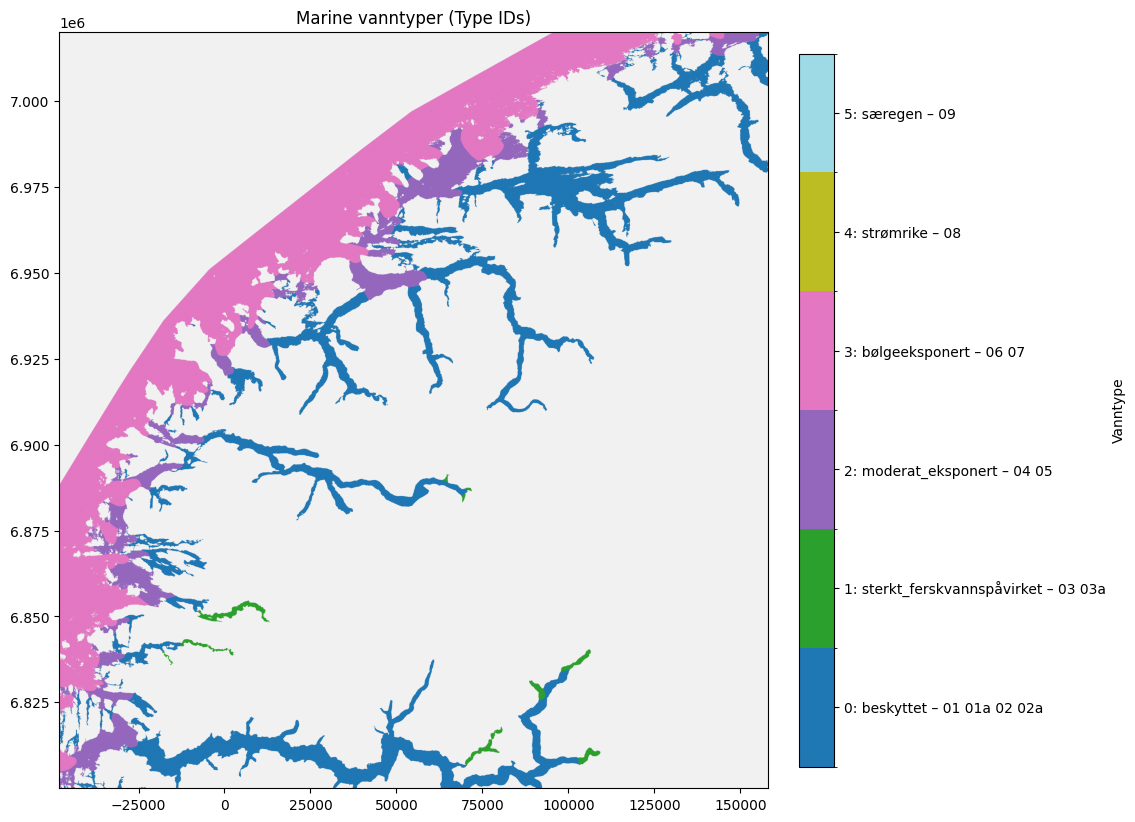

In [9]:
utils.plot_vanntyper(marine_type_raster, transform, id_type_map)


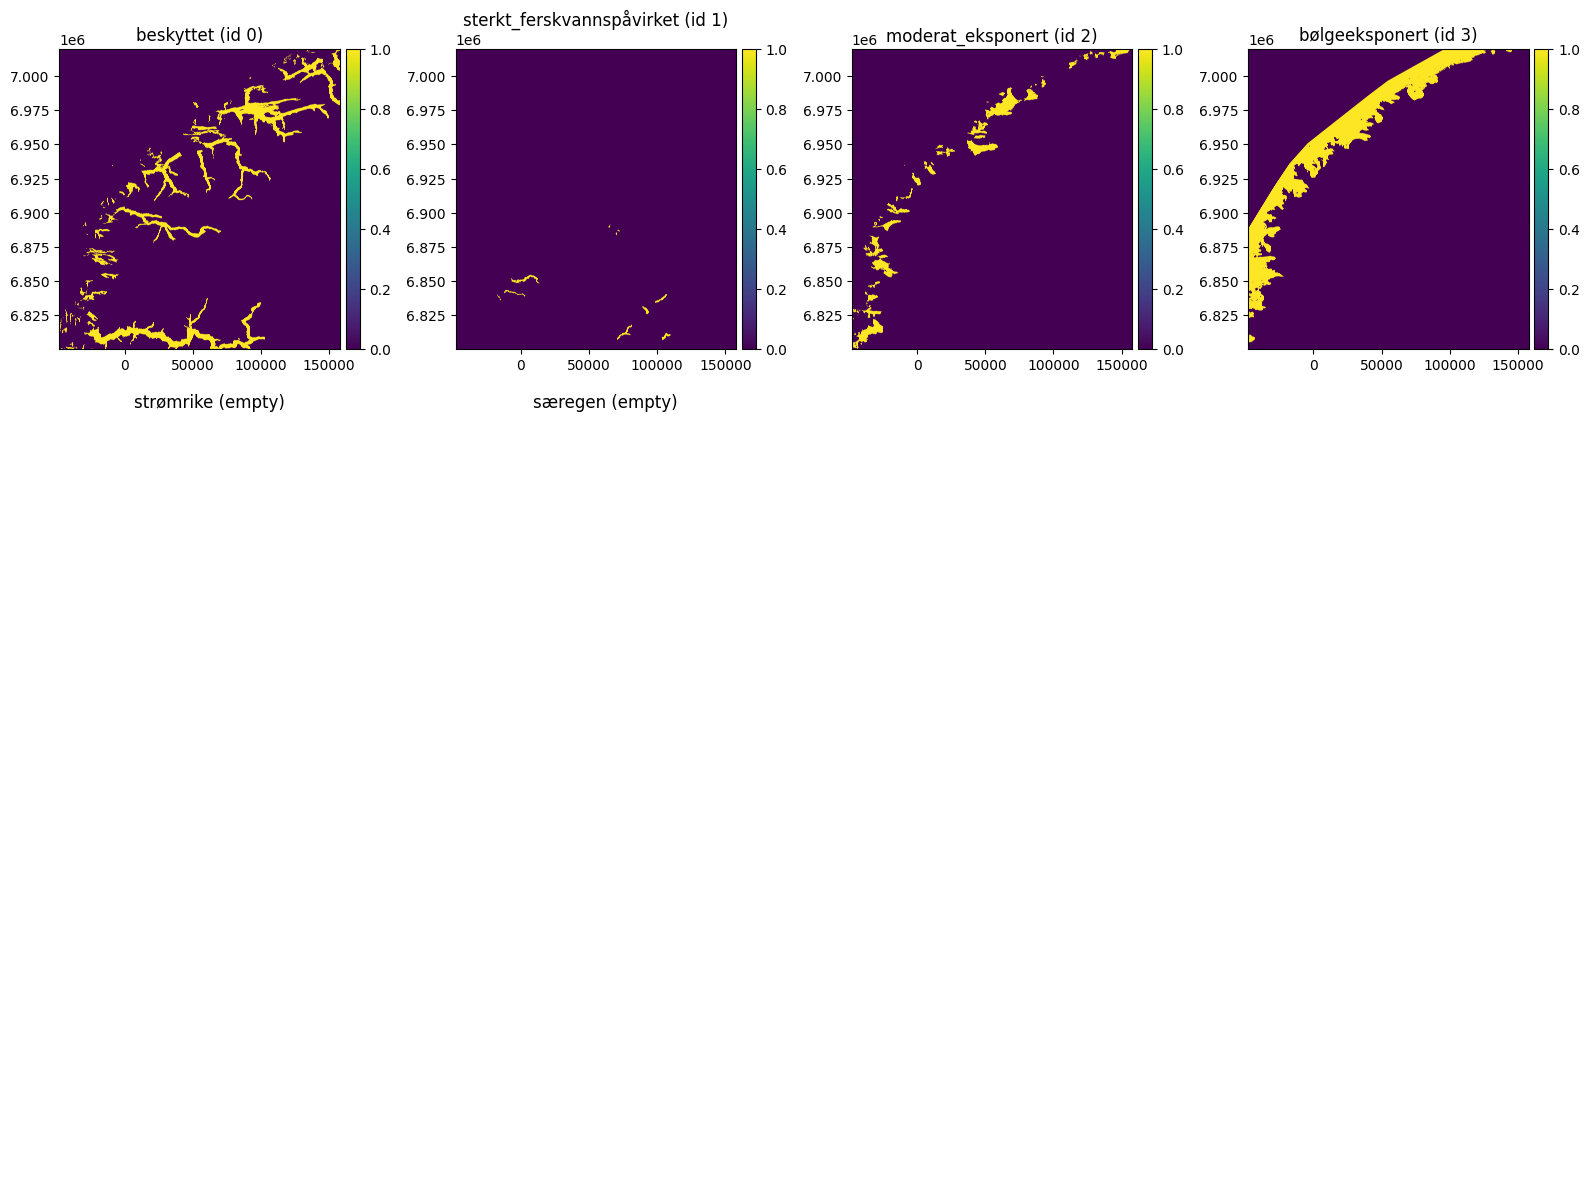

In [11]:

# Plot the first one-hot marine type layer using geoutils
# Check if all values in one_hot_types are zero
utils.plot_one_hot_vanntyper(one_hot_types, id_type_map, transform, dem.crs)



## Dataset for labels

Using NGU bunnsedimenter detaljert

In [4]:
gdf_bunn_full = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet")
gdf_bunn_full = gdf_bunn_full.to_crs(dem.crs)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

['blanding/uspesifisert', 'fastbunn', 'løsbunn']

In [17]:
# Requires gdf_bunn_full already in dem.crs (done in a previous cell)

# Map BunnType to label values
mapping_values = {"løsbunn": 0,
                  "blanding/uspesifisert": 1,
                  "fastbunn": 2}

# Prepare shapes as (geometry, value)
shapes = [
    (geom, mapping_values[btype])
    for geom, btype in zip(gdf_bunn_full.geometry, gdf_bunn_full["BunnType"])
    if btype in mapping_values
]

# Rasterize to uint8 with fill=255 for "other/none"
bunn_raster = rio.features.rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=transform,
    fill=255,
    dtype=np.uint8,
    all_touched=True,
)

In [10]:

depth = np.ma.filled(dem.data, np.nan).astype(np.float16)
features = np.concatenate(
    [np.stack([slope, aspect, curvature, depth], axis=-1), one_hot_types.astype(np.float16)],
    axis=-1
)
features.shape

(8800, 8240, 10)

In [30]:
valid_attrs = (~np.isnan(slope)) & (~np.isnan(aspect)) & (~np.isnan(curvature))
valid_bunn = np.isin(bunn_raster, tuple(mapping_values.values()))
valid = valid_attrs & valid_bunn

X = features[valid]
y = bunn_raster[valid].astype(np.uint8)  # labels: {0,1,2}

# Compute class weights from actual label distribution
classes = np.array(list(mapping_values.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
class_weights

{0: 0.6782460332766058, 1: 3.310904430477056, 2: 0.8172762396193601}

In [33]:
is_hyperparameter_tuning = False
if is_hyperparameter_tuning:
    param_dist = {
        'n_estimators': [100, 300, 500],
        'max_depth': [10, 20],
        'min_samples_leaf': [4, 10],
        'min_samples_split': [5, 10],
        'max_features': ['sqrt', 0.5]
    }

    rf = RandomForestClassifier(n_jobs=2, class_weight=class_weights)

    random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=10, cv=2, verbose=3, random_state=42)
    random_search.fit(X_train, y_train)

    rf = random_search.best_estimator_

    print("Best parameters found:", random_search.best_params_)


else:
    best_params = {
        'n_estimators': 100,
        'max_depth': 20,
        'min_samples_leaf': 4,
        'min_samples_split': 5,
        'max_features': 'sqrt'
    }

    rf = RandomForestClassifier(n_jobs=2, class_weight=class_weights, **best_params)

rf.fit(X_train, y_train)
print("Train accuracy:", rf.score(X_train, y_train))
print("Validation accuracy:", rf.score(X_val, y_val))

Train accuracy: 0.6791287696737132
Validation accuracy: 0.6328751149011526


In [ ]:
dump(rf, "randomforest_best.joblib")

depth: 0.2993
curvature: 0.2562
slope: 0.2200
aspect: 0.1528
bølgeeksponert: 0.0362
beskyttet: 0.0200
moderat_eksponert: 0.0129
sterkt_ferskvannspåvirket: 0.0026
strømrike: 0.0000
særegen: 0.0000


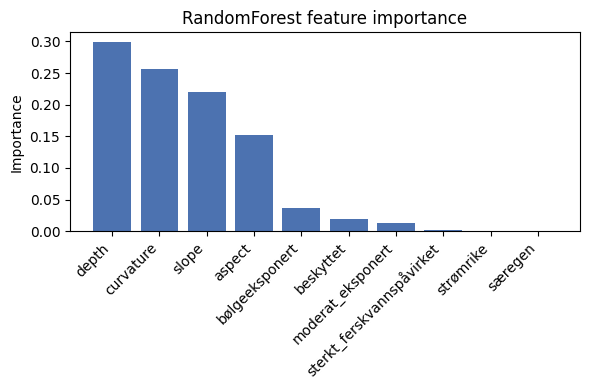

In [35]:
import numpy as np

# Feature importance for the trained RandomForest (features: slope, aspect, curvature, depth)
import matplotlib.pyplot as plt

feature_names = ["slope", "aspect", "curvature", "depth", "beskyttet", "sterkt_ferskvannspåvirket", "moderat_eksponert", "bølgeeksponert", "strømrike", "særegen"]
importances = rf.feature_importances_

# Print sorted importances
order = np.argsort(importances)[::-1]
for i in order:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

# Bar plot
plt.figure(figsize=(6, 4))
plt.bar([feature_names[i] for i in order], importances[order], color="#4C72B0")
plt.title("RandomForest feature importance")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Predict for AOI

In [36]:

gdf_bunn_moere = gpd.read_file("https://storage.googleapis.com/niva-geodata/MarintNaturKart/bunn_in_kommuner_sea.geojson")


In [37]:
# Use geoutils to clip the DEM by the gdf_bunn_moere polygons

# Ensure polygons are in DEM CRS
gdf_clip = gdf_bunn_moere.to_crs(dem.crs)

# Wrap inputs with geoutils
vec_clip = gu.Vector(gdf_clip)


In [38]:
vect_rasterized = vec_clip.create_mask(dem)
vect_rasterized.plot(ax="new")

: 

In [ ]:
arr2d = np.array(dem.data, dtype=np.float16)
arr2d[~vect_rasterized.data] = np.nan
dem_clipped = xdem.DEM.from_array(arr2d, transform=dem.transform, crs=dem.crs)

In [ ]:
dem_clipped.plot()

In [ ]:
cropped_attributes = xdem.terrain.get_terrain_attribute(
    dem_clipped.data,
    resolution=dem_clipped.res,
    attribute=["slope", "aspect", "curvature"],
)

In [ ]:
cropped_slope, cropped_aspect, cropped_curvature = cropped_attributes[0], cropped_attributes[1], cropped_attributes[2]

In [ ]:
depth_clipped = np.ma.filled(dem_clipped.data, np.nan).astype(np.float16)
features = np.stack([cropped_slope, cropped_aspect, cropped_curvature, depth_clipped], axis=-1)
valid_attrs = (~np.isnan(cropped_slope)) & (~np.isnan(cropped_aspect)) & (~np.isnan(cropped_curvature))

cropped_X = features[valid_attrs]

In [ ]:
Y_pred = rf.predict(cropped_X)

In [ ]:
pred_map = np.full(dem_clipped.data.shape[-2:], np.nan, dtype=np.float16)
pred_map[valid_attrs] = Y_pred.astype(np.float16)

In [ ]:

pred_raster = gu.Raster.from_array(pred_map, transform=dem_clipped.transform, crs=dem_clipped.crs)


In [ ]:
pred_raster.plot()

In [ ]:
pred_vec = pred_raster.polygonize()

In [ ]:
# Map raster_value (0/1) to BunnType using existing mapping_values
reverse_map = {v: k for k, v in mapping_values.items()}
pred_vec["BunnType"] = pred_vec["raster_value"].map(reverse_map)

pred_vec["BunnType"]

In [ ]:
gdf_final = pred_vec.ds.dissolve(by="BunnType", as_index=False, method="coverage")

In [ ]:
gdf_final = gdf_final.to_crs("EPSG:25833")

In [ ]:
fname = utils.to_filename("nisjedata-substrat-randomforest", "moere-og-romsdal", "latest", gdf_final.crs.to_epsg())
gdf_final = gdf_final.drop(columns=["depth_range", "class"], errors="ignore")
gdf_final.to_file(f"{fname}.geojson", driver="GeoJSON")

In [ ]:
gdf_final.to_file(f"{fname}.gpkg", layer="soft_hard_bottom", driver="GPKG")